In [18]:
import tensorflow as tf
import numpy as np

In [19]:
xy = np.loadtxt('./data/data-04-zoo.csv', delimiter=',', dtype=np.float32)
 
x_data = xy[:, 0:-1] # 학습 데이터, 처음 부터 마지막 데이터 직전까지 정답 데이터제외
y_data = xy[:, [-1]] # 정답 데이터

In [20]:
print(x_data.shape, y_data.shape)

# head 정보 포함한 데이터 shape

(101, 16) (101, 1)


In [21]:
x_data[0]

array([1., 0., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0., 4., 0., 0., 1.],
      dtype=float32)

In [22]:
y_data[2]

array([3.], dtype=float32)

In [23]:
# 원 핫 인코딩 방식(to_categorical() 함수)
nb_classes = 7  # 0, 1, ...6

# y_data 정답 데이터를 첫번째 매개변수, 몇개의 클래스인가
y_one_hot = tf.keras.utils.to_categorical(y_data, nb_classes) # 출력단은 총 출력의 갯수만큼 만들어져야 함(해당 되는 row는 1, 나머지는 전부 0)
y_one_hot

# 사전 데이터 생성


array([[1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0.],
 

In [24]:
# tensorflow를 이용한 신경망 구성
model = tf.keras.Sequential()

In [25]:
# model.add(tf.keras.Input(shape=(8,)))
# 범용적으로 동작
# 입력 레이어 추가
model.add(tf.keras.Input(shape=(x_data.shape[1], ))) # x_data.shape[1]  컬럼의 갯수를 열의 값으로 셋팅

# 출력 레이어 추가
model.add(tf.keras.layers.Dense(units=nb_classes, activation='softmax'))  # 분류 모델이 여러 개(현재 데이터는 출력단이 7개, 'sigmoid' 7개 구성)


In [26]:
# 다중 뷴류일 경우 손실 함수의 이름은 categorical_crossentropy
# 경사하강법 알고리즘 적용 tf.keras.optimizers.SGD
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              metrics=['accuracy'])

In [27]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119 (476.00 B)

 Trainable params: 119 (476.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
loss = model.fit(x_data, y_one_hot, epochs=1000)  # y_one_hot 전처리 수행한 모델

Epoch 1/1000


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1980 - loss: 2.2691      
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4059 - loss: 1.8422
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4257 - loss: 1.6744 
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5248 - loss: 1.4970 
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6139 - loss: 1.3685 
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6931 - loss: 1.2476 
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8020 - loss: 1.1407 
Epoch 8/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8119 - loss: 1.0649 
Epoch 9/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7822 - loss: 0.9990 
Epoch 10/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7723 - loss: 0.9313 
Epoch 11/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7822 - loss: 0.8878 
Epoch 12/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8020 - 

In [ ]:
pred = model.predict(x_data[[72]])  # 임의의 1개 72번째 데이터
pred

# 0,1,2,3,...6 클래스 중 마지막 클래스가 8.39024901e-01(84% 정도) 정확도를 나타냄 => 6번째 클래스를 예측

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


array([[4.07515327e-03, 1.99197224e-04, 3.65355127e-02, 4.16329327e-09,
        1.34946490e-02, 1.06670454e-01, 8.39024901e-01]], dtype=float32)

In [32]:
x_data[[72]]

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 8., 1., 0., 0.]],
      dtype=float32)

In [ ]:
pred.argmax(axis=1) # y축 기준으로 해당 데이터 셋의 가장 큰 값의 인덱스 반환
# 6번째 클래스

array([6])

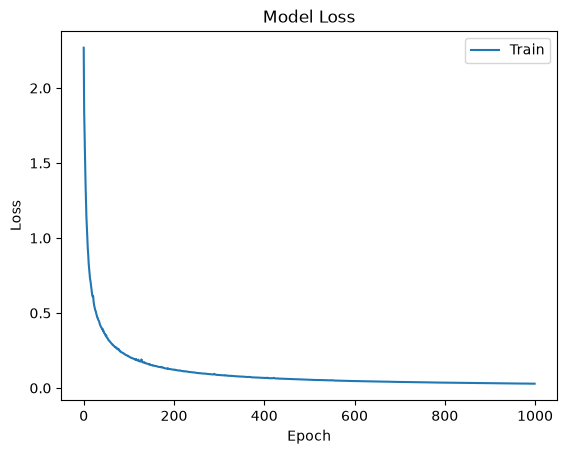

In [34]:
# loss 값의 시각화
import matplotlib.pyplot as plt

plt.plot(loss.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train'], loc='upper right')
plt.show()

